# Egydimenziós kinematikai számítások numerikus közelítéssel

## Fizika informatikusoknak géptermi gyakorlat

### v 2026/0.96

Ez a notebook azt mutatja be, hogy közelítő módszerrel hogyan lehet a hely → sebesség → gyorsulás utat, illetve fordítottját bejárni. 

Ez a módszer a gyakorlatban olyankor lehet hasznos, ha függvénnyel adott a probléma, de azokat nem papíron, egyenletként kezelni. (Mert pl. bonyolut függvényeket kellene integrálni, deriválni, vagy zérushelyeket keresni.)

Hasonló módszerrel mérési adatokból is lehet számításokat végezni. Ez egy későbbi gyakorlat témája.

In [3]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    

## Alap matematikai rutinok

Nemcsak kinematikára jók, ezért az általános $f(x)$ jelölést használjuk. Tehát $x$ nem a koordináta itt, hanem az általános független változó.


In [4]:
# Egy függvényt kiértékel a beadott tömb minden pontjában:

def calc_function(xx_tab, fun):
    return np.vectorize(fun)(xx_tab)

In [5]:
# 1D deriváló rutin a NumPy átlalánosabb eljárását meghívva.
# Ez középen centrális deriváltakat használ, a széleken egy speciális módszert, amit itt nem részletezünk.

def deriv(xx_tab, ff_tab):  
    return np.gradient(ff_tab, xx_tab, edge_order=2)

In [6]:
# Általános integráló rutin. 
# A trapézszabály alapján integrál, azaz a görbe alatti terület trapézok sorozatával közelíti.
# Erre sajnos nincs kész NumPy eljárás.

def integ(xx_tab, ff_tab, F0=0.0):
    intff=np.zeros_like(xx_tab)  # az integrál értékek tömbje
    intff[0]=F0
    intff[1:]=F0+np.cumsum((xx_tab[1:]-xx_tab[:-1])*(ff_tab[1:]+ff_tab[:-1])/2.0)   # cumsum= felösszegzés
    return intff 

$$F(x)=F_0+\int_0^x f(x') dx'$$

$$F(x_n)\approx F_0 + \sum_{i=1}^n \frac{f(x_i)+f(x_{i-1})}{2}\cdot (x_i-x_{i-1})$$

## Néhány hely-idő függvény gyakorlásnak

In [7]:
# Paraméterezhetőség: ezek a függvények egy felparaméterezett függvénnyel térnek vissza.

# Egyenes vonalú egyenletesen gyorsuló mozgás:
def make_xt_conts_acc(x0, v0, a):
    
    def fun(t):  
        return(x0+v0*t+(a/2)*t**2)
    
    return fun

# Harmonikus rezgés:
def make_xt_harm(A,omega,phi0=0.0):
    
    def fun(t):  
        return(A*np.sin(omega*t+phi0))
    
    return fun

# Csillapodó rezgés:
def make_xt_damped(A,omega,phi0=0.0,beta=0.0):
    
    def fun(t):  
        return(A*np.sin(omega*t+phi0)*np.exp(-beta*t))
    
    return fun
    

# Rossz hely-idő függvény szakadással:
def make_xt_jump(A,omega,phi0=0.0, t_jump=0.0, x_jump=0.0):
    
    def fun(t):    
        harm=make_xt_harm(A,omega,phi0)
        return harm(t)+x_jump*(t>t_jump)
        
    return fun
    
# Gauss-görbe:
def make_xt_Gauss(A, t0, sigma):
    
    def fun(t):
        return(A*np.exp(-(t-t0)**2/(2*sigma**2)))
    
    return fun

# Kinyit-becsuk
def make_xt_openclose(A, t0, width):
    
    def fun(t):
        return (A*(1.0-((t-t0)/width)**4)**3)*(np.abs(t-t0)<=width)
   
    return fun

## Egyszerű használat

In [8]:
# időértékek tömbje: t_max, dt időköz
dt=0.01
t_max=4.0
t=np.arange(0.0, t_max, dt, dtype=np.float64)

In [9]:
# Egyszerű példa: kő feldobása 17 m magasról, 10 m/s kezdősebességgel, g=9.81 mellett
xt_work=make_xt_conts_acc(17.0, 10.0, -9.81)  

In [10]:
x=calc_function(t, xt_work)  # feltöltjük x_tab-ot az előző függvény alapján

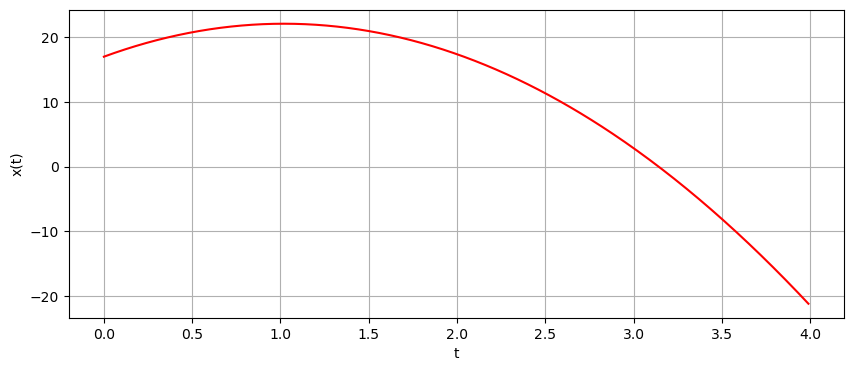

In [11]:
# Ellenőrzés: milyen ez a függvény:
fig=plt.figure(figsize=(10,4))  
ax1=fig.add_subplot(111)
ax1.set_xlabel("t")
ax1.set_ylabel("x(t)")
ax1.grid()
ax1.plot(t, x, color="red") 

## Kinematika odafelé: $x(t) \to v(t) \to a(t)$

In [12]:
v=deriv(t, x)  # Csak meghívjuk a deriváló rutint
a=deriv(t, v)  

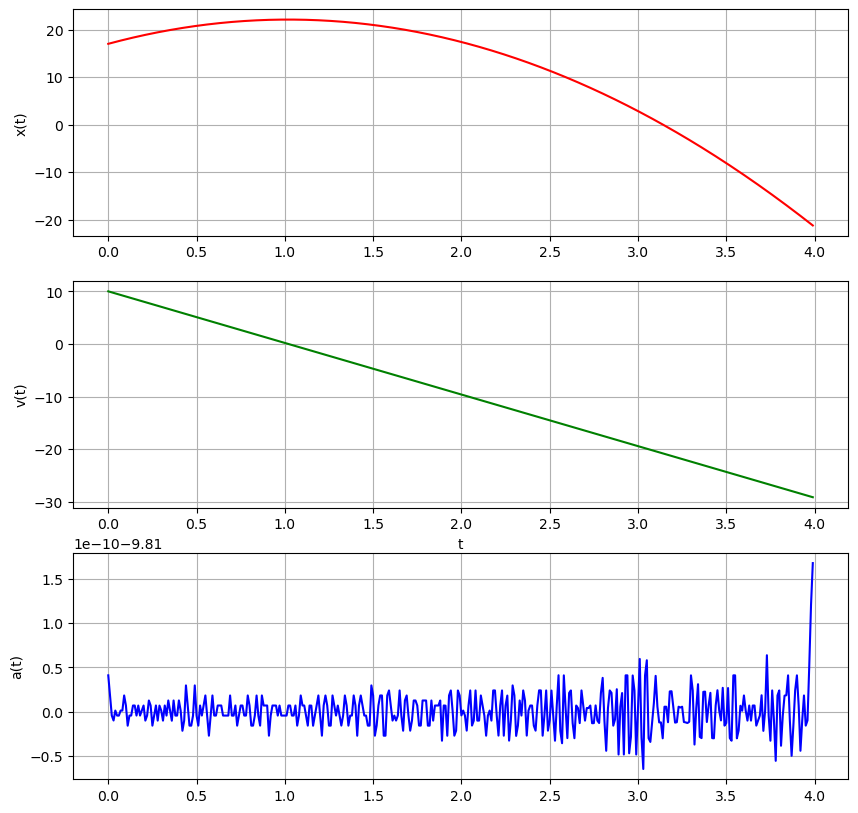

In [13]:
# rajzoljuk ki őket egymás alá
fig=plt.figure(figsize=(10,10))  # nagyobb rajzméret
ax1=fig.add_subplot(311) # három rész-grafikon
ax2=fig.add_subplot(312)
ax3=fig.add_subplot(313)
ax1.set_ylabel("x(t)")
ax1.plot(t, x, color="red") # az elsőbe az x(t)
ax2.set_ylabel("v(t)")
ax2.plot(t, v, color="green") # a másodikba a v(t)
ax3.set_ylabel("a(t)")
ax2.set_xlabel("t")
ax3.plot(t, a, color="blue") # a harmadikba az a(t)
ax1.grid()
ax2.grid()
ax3.grid()

Figyeljük meg a skálázást a tengelyeken! 

Az eredeti példában a gyorsulás elvileg -9.81, de a kerekítések miatt ingadozik 1e-10 nagységrendben.

## Más függvényekre:

In [14]:
## Más hely-idő függvénnyel:
#xt_work=make_xt_conts_acc(17.0, 10.0, -9.81)  # kő feldobása 17 m magasról, 10 m/s kezdősebességgel, g=9.81 mellett
xt_work=make_xt_harm(2.0, 1.5, 0.0) 
#xt_work=make_xt_jump(2.0, 1.5, 0.0, 5.0, -1.2) 
#xt_work=make_xt_openclose(2.0, 4.0, 2.0)

In [15]:
t=np.arange(0.0, 10.0, 0.01, dtype=np.float64)
x=calc_function(t, xt_work)  # feltöltjük x_tab-ot az előző függvény alapján
v=deriv(t, x)  # kinematika
a=deriv(t, v)  # kinematika

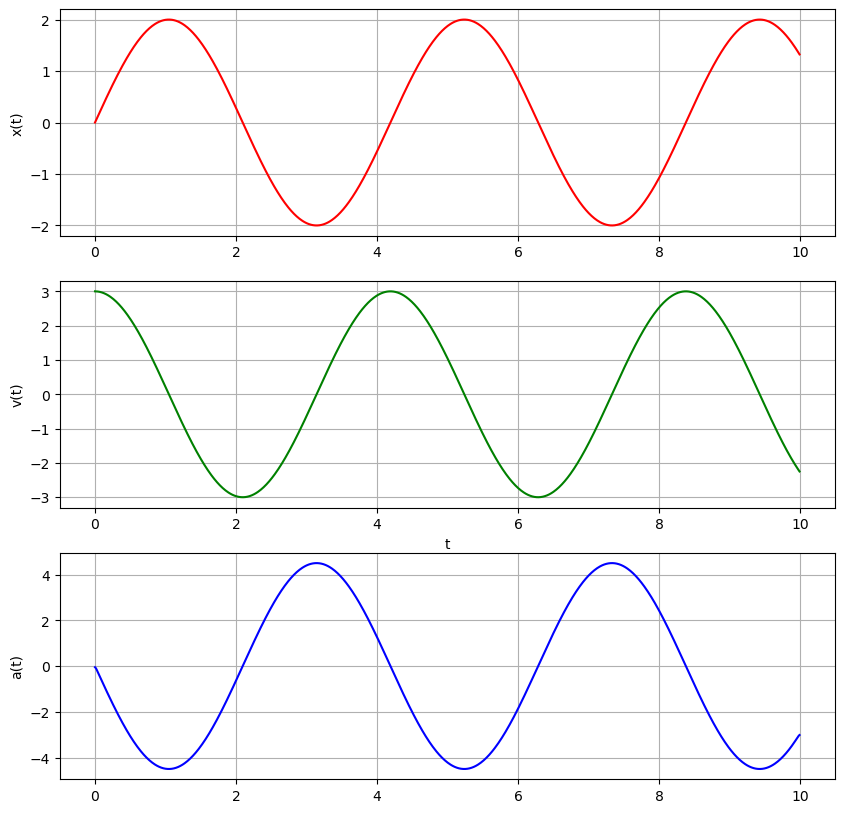

In [16]:
# ábrázolás
fig=plt.figure(figsize=(10,10))  # nagyobb rajzméret
ax1=fig.add_subplot(311) # három rész-grafikon
ax2=fig.add_subplot(312)
ax3=fig.add_subplot(313)
ax1.set_ylabel("x(t)")
ax1.plot(t, x, color="red") # az elsőbe az x(t)
ax2.set_ylabel("v(t)")
ax2.plot(t, v, color="green") # a másodikba a v(t)
ax3.set_ylabel("a(t)")
ax2.set_xlabel("t")
ax3.plot(t, a, color="blue") # a harmadikba az a(t)
ax1.grid()
ax2.grid()
ax3.grid()

**0. feladat:** próbálgassuk más függvényekkel az előző kirajzolásokat.

## Kinematika visszafele: $a(t)\to v(t)\to x(t)$

In [17]:
# Kipróbáljuk: visszakapjuk-e v(t)-t és x(t)-t, ha a kiszámolt a(t)-ből indulunk ki?

# Be kell adnunk egy kezdősebességet! Ha nem jól adjuk meg, rossz eredményt kapunk.
v0=3.0
re_v=integ(t, a, v0)  # a-ból v-t integrálással kapunk
# Be kell adnunk egy kezdő helyet! Ha nem jól adjuk meg, rossz eredményt kapunk.
x0=0.0
re_x=integ(t, re_v, x0)

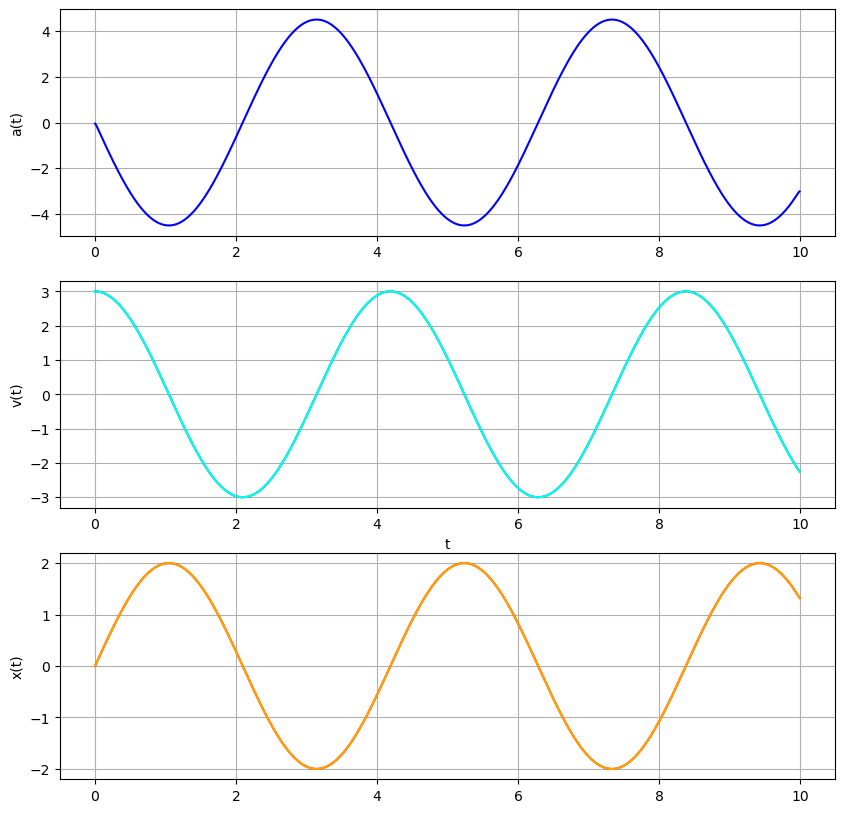

In [18]:
fig=plt.figure(figsize=(10,10))  # nagyobb rajzméret
ax1=fig.add_subplot(313) # három rész-grafikon
ax2=fig.add_subplot(312)
ax3=fig.add_subplot(311)
ax1.set_ylabel("x(t)")
ax1.plot(t, x, color="red") # az elsőbe az x(t)
ax1.plot(t, re_x, color="orange") # az elsőbe az x(t)
ax2.set_ylabel("v(t)")
ax2.plot(t, v, color="green") # a másodikba a v(t)
ax2.plot(t, re_v, color="cyan") # a másodikba a v(t)
ax3.set_ylabel("a(t)")
ax2.set_xlabel("t")
ax3.plot(t, a, color="blue") # a harmadikba az a(t)
ax1.grid()
ax2.grid()
ax3.grid()

In [19]:
# Szemmel nem látszik a különbség, ha v0-t és x0-t jól adtuk meg.
# Mérjük meg a visszanyert x értékek hibáját!
x_err=x-re_x
average_err=np.abs(x_err).mean()

print(f"Átlagos eltérés x és a visszaszámolt x értékek közt: {average_err:.3e}")

Átlagos eltérés x és a visszaszámolt x értékek közt: 7.258e-04


Kicsi, de nem teljesen elhanyagolható hiba.

Kérdés: hogyan csökkenthetnénk a hibát kis módosítással?

## Példamegoldás

Az előző órán tanultak felhasználásával

**Kidolgozott feladat:**

Egy emelkedő léghajóról eloldunk egy homokzsákot abban a pillanatban, amikor az 15 m magasan van és 6 m/s sebességgel emelkedik.
   * Az eloldás után mennyivel fog a földbe csapódni?
   * Milyen sebességű lesz a becsapódás?
   * A becsapdásig mekkora a zsák teljes megtett útja?

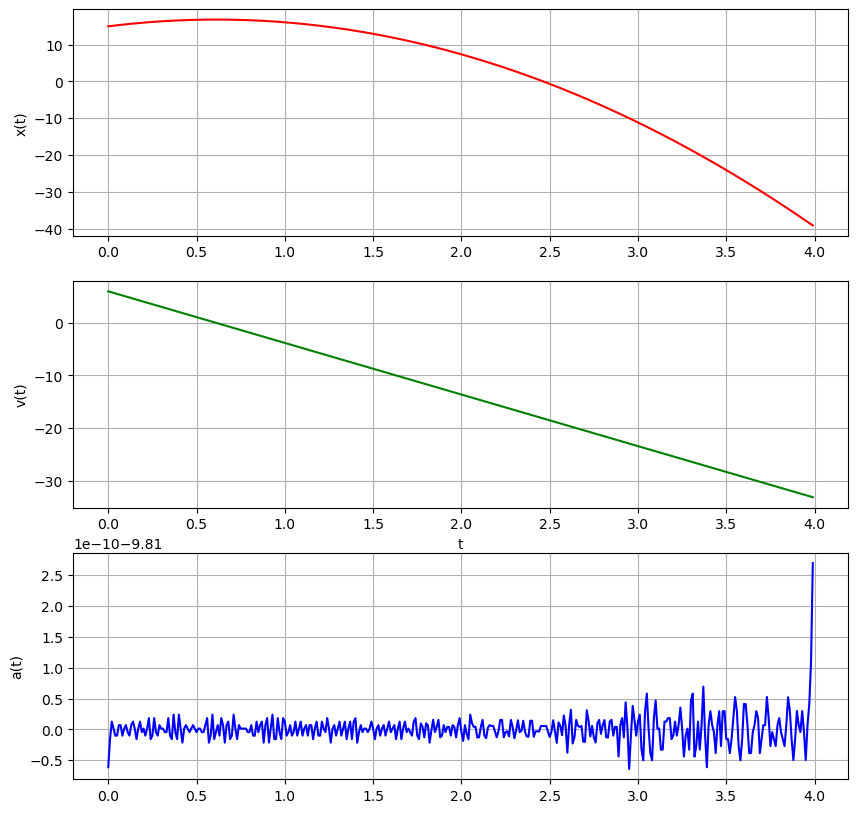

In [20]:
# A feladat "digitalizálása".

# Kezdjük egy t tengellyel. Becslés: 4 s talán elég a földbe csapódásig.
t=np.arange(0.0, 4.0, 0.01, dtype=np.float64)

# szöveg szerinti mozgás állnadó gyorsulással:
xt_work=make_xt_conts_acc(15.0, 6, -9.81)

# x feltöltése, majd ebből v és a számolása
x=calc_function(t, xt_work)  # feltöltjük x_tab-ot az előző függvény alapján
v=deriv(t, x)  # kinematika
a=deriv(t, v)  # kinematika

# hihető ez? Plottoljunk!

fig=plt.figure(figsize=(10,10))  # nagyobb rajzméret
ax1=fig.add_subplot(311) # három rész-grafikon
ax2=fig.add_subplot(312)
ax3=fig.add_subplot(313)
ax1.set_ylabel("x(t)")
ax1.plot(t, x, color="red") # az elsőbe az x(t)
ax2.set_ylabel("v(t)")
ax2.plot(t, v, color="green") # a másodikba a v(t)
ax3.set_ylabel("a(t)")
ax2.set_xlabel("t")
ax3.plot(t, a, color="blue") # a harmadikba az a(t)
ax1.grid()
ax2.grid()
ax3.grid()

Szemrevételezés: 2.5 s körül csapódik be. Elég lett volna rövidebb időtartamra számolni.

Az is előfordulhatna, hogy túl kicsi időintervallumot választunk. Ekkor növelni kellene, hogy a becsapódás bekövetkezzen a vizsgálat alatt.

In [21]:
## Kérdés: Az eloldás után mennyivel fog a földbe csapódni?
# Földbe csapódás: x(t)=0.0
# Pontos egyezés helyett, csak minimális eltérés:

# mint a múlt órán:
ind_impact=np.abs(x).argmin()   # becsapódás indexe
# ebből megvan az időpont:
print(f"A földetérés ideje: {t[ind_impact]:.3f} s.")

A földetérés ideje: 2.460 s.


In [22]:
## Kérdés: Milyen sebességű lesz a becsapódás?
# az előzőleg kiszámolt ind_impact mondja meg, melyik tömbelemet kell kiolvasnunk.
# de most v-ből olvassuk ki, nem t-ből:
print(f"A földetérés sebessége: {v[ind_impact]:.3f} m/s.")

A földetérés sebessége: -18.133 m/s.


In [23]:
## Kérdés: A becsapdásig mekkora a zsák teljes megtett útja?
# Út: elmozdulások összege

# a múlt órai anyag alapján:
s=np.append([0], np.abs(np.diff(x)).cumsum())
print(f"A földetérésig megtett út: {s[ind_impact]:.3f} m.")

A földetérésig megtett út: 18.593 m.


**1. feladat:**

Az előző hajítási problémában:
   * Mekkora a maximális magasság és mikor érte azt el a test?
   * Mekkora a kezdettől a becsapódásig az össz elmozdulás (nem út!)?

**2. feladat:**

A fenti "openclose" függvény egy szelep nyitásának és csukásának függvénye. Megmértük egy konkrét esetben, hogy A=15 mm, t0=10 ms, width=3.2 ms volt. (Azaz a 10 ms környékén volt 15 mm-nyit nyitva és a nyitás ezelőtt 3.2 ms-mal kezdődött, ez után 3.2 ms-mal végződött.)

   * Mikor volt a legnagyobb a sebessége a szelepnek és mekkora volt ennek nagysága?
   * Mikor volt a legnagyobb a gyorsulása a szelepnek és mekkora volt ennek nagysága?
   * Hogyan változnak az előző értékek, ha a nyitás ideje feleződik?
   
(Vigyázat! Az időlépés és maximális időtartam választás nagyon más, mint korábban!)

**3. feladat:**

A fenti "damped" függvény egy csillapodó rezgőmozgást ír le. Legyenek ennek paraméterei: A=0.2, omega=3.5, phi0=0.0, beta=0.3.

   * Rajzolja ki az x(t), v(t) és a(t) függvényeket 0 és 10 s között!
   * Mekkora a legnagyobb fellépő gyorsulás?
   * Rajzolja ki az idő függvényében az addig megtett utat!
   * A kezdettől számítva mikor éri el az össz megtett út az 1 m-t?

## Általánosabb számítások

Az előzőekben $x(t)$-ből indultunk ki, ebből lett $v(t)$ majd $a(t)$. A visszafelé utat csak önellenőrzésként használtuk.

A gyakorlatban lehet, hogy a bemenő adat a sebesség vagy a gyorsulás időfüggése. Ezekből is el lehet indulni a fenti módszerekkel.

Emlékeztető az előadásról: 
$$v=\frac{d x}{dt};\qquad a=\frac{d v}{d t}$$
$$v(t)=v_0+\int_{t_0}^t a(t') dt'; \qquad x(t)=x_0+\int_{t_0}^t v(t') dt'$$



In [24]:
# Példa: v(t) és x_0 adott:

**Kidolgozott feladat:**

Egy test kezdetben az $x_0=7$ m helyen tartózkodik és sebessége az idő függvényében a $$v(t)=3\cdot e^{-t/2}\cdot\sin(10t)-\frac{4}{t+3}$$ függvény szerint változik.

   * Rajzolja ki a hely-idő, sebesség-idő és gyorsulás-idő függvényeit 0 és 20 s között!
   * Eléri-e a test az origót?

In [25]:
# a feladat szerint:
t=np.arange(0.0, 20.0, 0.01, np.float64)

v=3*np.exp(-t/2.0)*np.sin(10*t) - 4/(t+3)   # nem kellett def-fel függvényt létrehozni

x_0=7.0

In [26]:
# Kinematika: x(t)-t integrálással, a(t)-t defriválással kapjuk meg:

x=integ(t, v, x_0)
a=deriv(t, v)

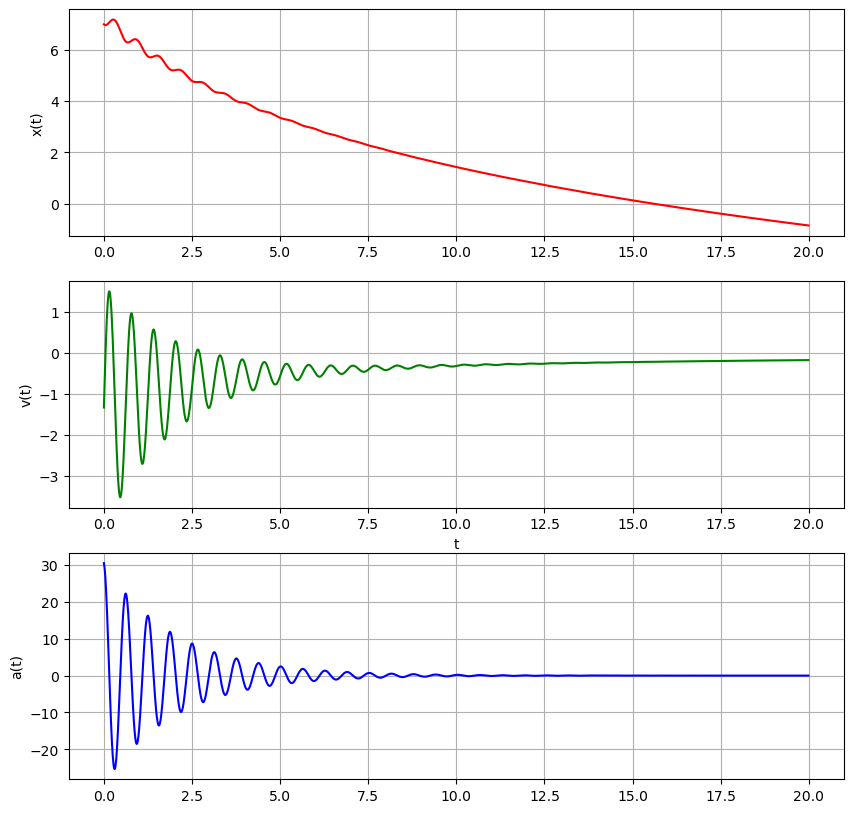

In [27]:
# rajzoljuk ki őket egymás alá
fig=plt.figure(figsize=(10,10))  # nagyobb rajzméret
ax1=fig.add_subplot(311) # három rész-grafikon
ax2=fig.add_subplot(312)
ax3=fig.add_subplot(313)
ax1.set_ylabel("x(t)")
ax1.plot(t, x, color="red") # az elsőbe az x(t)
ax2.set_ylabel("v(t)")
ax2.plot(t, v, color="green") # a másodikba a v(t)
ax3.set_ylabel("a(t)")
ax2.set_xlabel("t")
ax3.plot(t, a, color="blue") # a harmadikba az a(t)
ax1.grid()
ax2.grid()
ax3.grid()

In [28]:
# A grafikon alapján a test eléri az origót. Ennek ideje:

ind_orig=np.argmin(np.abs(x))
t_orig=t[ind_orig]

print(f"A test az origót a t={t_orig:.2f} s időpontban éri el.")

A test az origót a t=15.60 s időpontban éri el.


Megjegyzés: ez az origó-elérés keresés nem a legjobb, mert akár többször is elérhetné azt. A többszörös megoldásokkal később foglalkozunk.

**4. feladat:**

Egy test gyorsulás-idő függvénye:
$$a(t)=6.2t-8t^2$$
Kezdeti sebessége 10 m/s és az origóból indul.

   * Rajzolja ki a hely-, sebesség- és gyorsulásfüggvényt 0 és 5 s között.
   * Mikor lesz 0 a sebessége?
   * Mikor ér vissza az origóba? (Trükkösen ki kell zárni, hogy az origóból indult!)

## Új NumPy eljárások:

   * `np.gradient(ff, xx)`: a táblázattal adott f(x) függvény deriváltját közelíti

_Záró megjegyzés:_

Ez a munkalap mutatja, magyarázza az ötleteket, lépésről lépésre vezetve be új "trükköket". 
Nem célszerű ezt a gyakorlatban így használni közvetlenül, mert sorra ugyanazokat a változóneveket használtuk (x, v, t, ...), amibe könnyű belezavarodni.

Később a kavarodás elkerülése végett egyszerű objektumokba tesszük majd az egy mozgsához tartozó tömböket.